# 06 — Momentum / Reversal signal (Layer 2)

Signal 2 of the layered system (`docs/trading_bot_layers.md`): monthly
cross-sectional price momentum + short-term reversal on the same universe,
evaluated under the same honest protocol as the transcript model (tune on
the first 70% of rebalance dates, report on the untouched last 30%).

This is the **benchmark layer**: free data, fires monthly on every name.
Any fancier signal (including ECA itself, in ensemble) has to justify
itself against this.

In [1]:
import sys
sys.path.insert(0, '..')
import sqlite3, warnings
import numpy as np, pandas as pd
import lightgbm as lgb, optuna
from scipy.stats import spearmanr
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore', category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', context='notebook')
from src.momentum import (build_momentum_panel,
    MOMENTUM_COMPOSITE_SIGNS, add_composite_score)
from src.config import BENCHMARKS, DB_PATH

HOLD_DAYS = 21                    # ~1 trading month, non-overlapping rebalances
TUNE_FRAC = 0.70                  # first 70% of rebalance DATES: tuning only
N_EVAL_FOLDS = 3                  # expanding walk-forward folds on the eval tail
COST_BPS = 10.0                   # round-trip spread+slippage per unit notional
BORROW_BPS_ANNUAL = 50.0          # short-leg borrow
%matplotlib inline

In [2]:
# ---- Monthly feature/target panel via src/momentum.py --------------------
# NOTE: notebook 01 pulls prices with yfinance auto-adjust, so `close` IS the
# split/dividend-adjusted price (the "adj close" column is empty by design).
# New panel includes:
#  - Vol-adjusted features (mom/vol — the key anti-lottery-ticket fix)
#  - Sector-neutral ranks (the key anti-macro-bet fix)
#  - Beta-adjusted target (the key anti-bull-market-cheating fix)
conn = sqlite3.connect(DB_PATH)
px = pd.read_sql('SELECT date, ticker, close, volume FROM prices',
                 conn, parse_dates=['date'])
conn.close()
wide = px.pivot_table(index='date', columns='ticker', values='close', aggfunc='last').sort_index()
vol_wide = px.pivot_table(index='date', columns='ticker', values='volume', aggfunc='last').sort_index()

panel = build_momentum_panel(wide, volume_wide=vol_wide, benchmarks=BENCHMARKS)

feat_cols = [c for c in panel.columns if not c.startswith(('raw_target', 'target'))
             and c not in ('date', 'ticker', 'sector')]
print(f'panel: {len(panel):,} rows | {panel["ticker"].nunique()} tickers | '
      f'{panel["date"].nunique()} dates | avg {len(panel)/panel["date"].nunique():.0f} names/date')
print(f'features: {len(feat_cols)} (incl. vol-adjusted + sector-neutral variants)')


106 rebalance dates: 2017-07-31 -> 2026-04-30
panel: 62,756 rows | 614 tickers | 106 dates | avg 592 names/date


In [3]:
# ---- Composite benchmark: pure ranks, zero ML --------------------------
# Uses src.momentum.add_composite_score() with literature-derived signs.
panel = add_composite_score(panel, signs=MOMENTUM_COMPOSITE_SIGNS)

dates_u = np.sort(panel['date'].unique())
cut_date = dates_u[int(len(dates_u) * TUNE_FRAC)]
n_eval_dates = int((dates_u >= cut_date).sum())
print(f'tune < {pd.Timestamp(cut_date).date()} | eval {n_eval_dates} dates '
      f'to {pd.Timestamp(dates_u[-1]).date()} '
      f'(includes months AFTER the transcript corpus ends 2025-05 — fresh data)')

def ic_by_date(frame, pred_col, label, min_names=30):
    ics = (frame.groupby('date')[[pred_col, 'target']]
           .apply(lambda g: spearmanr(g[pred_col], g['target'])[0]
                  if len(g) >= min_names else np.nan).dropna())
    t = ics.mean() / ics.std() * np.sqrt(len(ics)) if ics.std() > 0 else float('nan')
    print(f'{label}: IC={ics.mean():+.4f}  t={t:+.2f}  '
          f'({(ics > 0).mean():.0%} of {len(ics)} dates positive)')
    return ics

def decile_spread(frame, pred_col):
    rp = frame.groupby('date')[pred_col].rank(pct=True)
    dm = frame.groupby(np.minimum((rp * 10).astype(int), 9))['target'].mean()
    return (dm.iloc[-1] - dm.iloc[0]) * 1e4, dm

ev_panel = panel[panel['date'] >= cut_date]
print('--- composite, eval region ---')
ics_comp = ic_by_date(ev_panel, 'composite', 'Composite')
sp_c, dm_c = decile_spread(ev_panel, 'composite')
print(f'Decile spread (D10-D1): {sp_c:+.0f} bps per month')

tune < 2023-09-29 | eval 32 dates to 2026-04-30 (includes months AFTER the transcript corpus ends 2025-05 — fresh data)
--- composite, eval region ---
Composite: IC=+0.0013  t=+0.03  (53% of 32 dates positive)
Decile spread (D10-D1): -150 bps per month


Optuna (20 trials, tune region only)...
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[3]	valid_0's rmse: 0.0839905
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[41]	valid_0's rmse: 0.187373
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.089944
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0908232
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[7]	valid_0's rmse: 0.0839956
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[74]	valid_0's rmse: 0.187132
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0898989
Training until validation scores don't improve for 15 rounds
Early stopping, be

Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[9]	valid_0's rmse: 0.0839512
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[99]	valid_0's rmse: 0.187245
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0898998
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0908797
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[17]	valid_0's rmse: 0.0839853
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[100]	valid_0's rmse: 0.187271
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[2]	valid_0's rmse: 0.0899048
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[3]	valid_0's rmse: 

Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[134]	valid_0's rmse: 0.186983
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0899443
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[7]	valid_0's rmse: 0.0908477
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[24]	valid_0's rmse: 0.0839463
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[172]	valid_0's rmse: 0.187246
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0898834
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[9]	valid_0's rmse: 0.0908763
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[28]	valid_0's rmse

Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[161]	valid_0's rmse: 0.18766
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0898846
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[20]	valid_0's rmse: 0.0908553
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[67]	valid_0's rmse: 0.0839588
Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[250]	valid_0's rmse: 0.187777
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0898879


Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[24]	valid_0's rmse: 0.0908325
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[46]	valid_0's rmse: 0.0839653
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[160]	valid_0's rmse: 0.187647
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[4]	valid_0's rmse: 0.0898878
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[19]	valid_0's rmse: 0.0908262
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[9]	valid_0's rmse: 0.0839737
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[37]	valid_0's rmse: 0.187414
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse

...

Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[33]	valid_0's rmse: 0.0839986
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[176]	valid_0's rmse: 0.187802
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0898942
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[21]	valid_0's rmse: 0.0908011
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0840178
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[34]	valid_0's rmse: 0.187158
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0899362
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse:

Early stopping, best iteration is:
[6]	valid_0's rmse: 0.0839783
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[115]	valid_0's rmse: 0.187292
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[2]	valid_0's rmse: 0.0899124
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[3]	valid_0's rmse: 0.0908556
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[42]	valid_0's rmse: 0.0839491
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[192]	valid_0's rmse: 0.187607


Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[2]	valid_0's rmse: 0.08988
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[17]	valid_0's rmse: 0.0908681
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[8]	valid_0's rmse: 0.0839582
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[80]	valid_0's rmse: 0.187145
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0899159
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[4]	valid_0's rmse: 0.0909137
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[11]	valid_0's rmse: 0.0839233
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[71]	valid_0's rmse: 0

Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[6]	valid_0's rmse: 0.0908632
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[18]	valid_0's rmse: 0.08398
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[230]	valid_0's rmse: 0.187392
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0898952
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[17]	valid_0's rmse: 0.0908755
best tune-CV RMSE: 0.112924


--- LightGBM, eval region ---
LightGBM : IC=+0.0258  t=+1.88  (59% of 32 dates positive)
Decile spread (D10-D1): +206 bps per month
model - composite IC: +0.0245 (paired t=+0.56) -> composite is (statistically) just as good


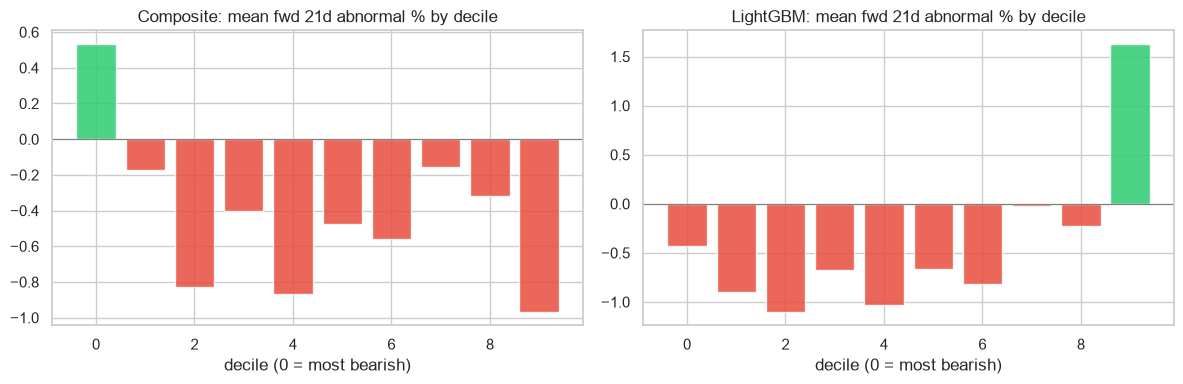

In [4]:
# ---- LightGBM under the shared honest protocol --------------------------
# Tune (Optuna, 20 trials) strictly on pre-cutoff rows; report via expanding
# walk-forward over eval DATES (fold boundaries on whole dates — no
# same-date rows split between train and test).
# Feature columns: everything in the panel except metadata/target
EXCLUDE = ['date', 'ticker', 'sector', 'target', 'raw_target', 'composite', 'pred_model']
FEATS = [c for c in panel.columns if c not in EXCLUDE]
print(f'{len(FEATS)} features for LightGBM')
X_all = panel[FEATS]
y_all = panel['target'].values
tune_mask = (panel['date'] < cut_date).values
X_tune, y_tune = X_all[tune_mask], y_all[tune_mask]
tscv = TimeSeriesSplit(n_splits=4)

def objective(trial):
    params = {'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 4, 16),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 0.9),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 0.9),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 50, 300),
        'lambda_l1': trial.suggest_float('lambda_l1', 0.5, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 0.5, 10.0, log=True),
        'verbose': -1, 'random_state': 42, 'num_threads': 8}
    scores = []
    for tr, vl in tscv.split(X_tune):
        m = lgb.train(params, lgb.Dataset(X_tune.iloc[tr], label=y_tune[tr]),
                      num_boost_round=250,
                      valid_sets=[lgb.Dataset(X_tune.iloc[vl], label=y_tune[vl])],
                      callbacks=[lgb.early_stopping(15), lgb.log_evaluation(0)])
        scores.append(np.sqrt(mean_squared_error(y_tune[vl], m.predict(X_tune.iloc[vl]))))
    return np.mean(scores)

print('Optuna (20 trials, tune region only)...')
study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20, show_progress_bar=False)
bp = dict(study.best_params)
bp.update({'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt',
           'verbose': -1, 'random_state': 42, 'num_threads': 8})
print(f'best tune-CV RMSE: {study.best_value:.6f}')

eval_dates = dates_u[dates_u >= cut_date]
panel['pred_model'] = np.nan
for fold in np.array_split(eval_dates, N_EVAL_FOLDS):
    tr_mask = (panel['date'] < fold[0]).values
    te_mask = panel['date'].isin(fold).values
    y_tr = y_all[tr_mask]
    lo, hi = np.nanquantile(y_tr, [0.01, 0.99])       # winsorize train labels only
    m = lgb.train(bp, lgb.Dataset(X_all[tr_mask], label=np.clip(y_tr, lo, hi)),
                  num_boost_round=300, callbacks=[lgb.log_evaluation(0)])
    panel.loc[te_mask, 'pred_model'] = m.predict(X_all[te_mask])

ev_panel = panel[panel['date'] >= cut_date]
print('--- LightGBM, eval region ---')
ics_model = ic_by_date(ev_panel, 'pred_model', 'LightGBM ')
sp_m, dm_m = decile_spread(ev_panel, 'pred_model')
print(f'Decile spread (D10-D1): {sp_m:+.0f} bps per month')

both = pd.concat([ics_comp.rename('comp'), ics_model.rename('model')], axis=1).dropna()
d = both['model'] - both['comp']
t_d = d.mean() / d.std() * np.sqrt(len(d)) if d.std() > 0 else float('nan')
print(f'model - composite IC: {d.mean():+.4f} (paired t={t_d:+.2f}) -> '
      + ('model earns its complexity' if d.mean() > 0 and t_d > 1.5
         else 'composite is (statistically) just as good'))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, dm, ttl in [(ax[0], dm_c, 'Composite'), (ax[1], dm_m, 'LightGBM')]:
    a.bar(dm.index, dm.values * 100,
          color=np.where(dm.values >= 0, '#2ecc71', '#e74c3c'), alpha=0.85)
    a.axhline(0, color='gray', lw=0.8)
    a.set_title(f'{ttl}: mean fwd {HOLD_DAYS}d abnormal % by decile')
    a.set_xlabel('decile (0 = most bearish)')
plt.tight_layout(); plt.show()

=== top/bottom decile, 21d hold, 10bps + borrow ===
Composite (spy-adj)  gross: Sharpe -0.76 | -149 bps/mo | maxDD -46.0% | hit 41% | 32 months
Composite (spy-adj)  net  : Sharpe -0.88 | -173 bps/mo | maxDD -50.0% | hit 38% | 32 months
LightGBM  (spy-adj)  gross: Sharpe +1.83 | +206 bps/mo | maxDD -11.7% | hit 69% | 32 months
LightGBM  (spy-adj)  net  : Sharpe +1.62 | +181 bps/mo | maxDD -12.7% | hit 66% | 32 months
LightGBM  (b-hedged) gross: Sharpe +1.19 | +129 bps/mo | maxDD -15.3% | hit 66% | 32 months
LightGBM  (b-hedged) net  : Sharpe +0.96 | +105 bps/mo | maxDD -16.3% | hit 62% | 32 months
(beta-hedged is the honest headline: the model tilts long high-beta/high-vol momentum, which pays mechanically vs SPY in a bull market)


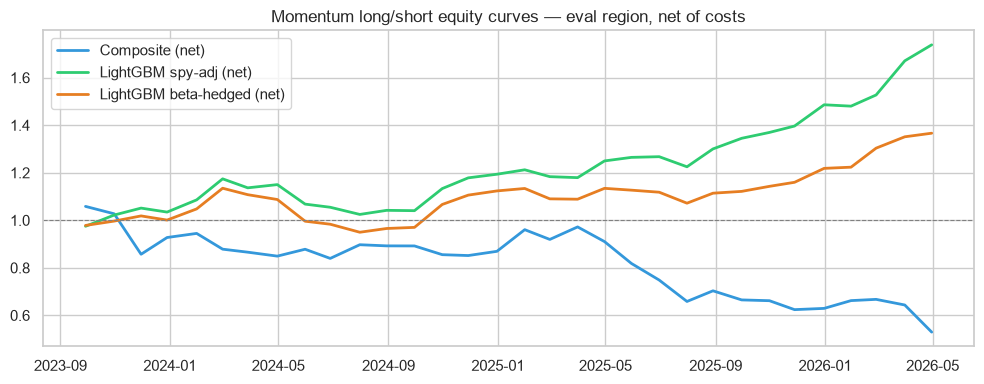

In [5]:
# ---- Cost-aware monthly long/short (eval region) -------------------------
# Two return accountings for the SAME book:
#   target      = r_i - r_spy        (SPY-adjusted; what the panel targets)
#   beta-hedged = r_i - beta_i*r_spy (removes the mechanical bull-market
#                 payoff of tilting long high-beta names — the model DOES
#                 tilt that way, so this is the honest headline)
spy_fwd = spy.shift(-HOLD_DAYS) / spy - 1
_b = pd.concat([beta_252.loc[d].reindex(panel.loc[panel['date'] == d, 'ticker']).set_axis(
                panel.index[panel['date'] == d]) for d in reb_dates])
panel['beta_hedged'] = panel['target'] - (_b - 1) * panel['date'].map(spy_fwd)
ev_panel = panel[panel['date'] >= cut_date]

def ls_series(frame, score_col, ret_col='target', top=0.10):
    rows = []
    # |w| = 2 per month (1 long + 1 short) -> round-trip costs on both legs,
    # borrow accrues on the short leg over the holding month.
    cost = 2 * (COST_BPS / 1e4) + (BORROW_BPS_ANNUAL / 1e4) * HOLD_DAYS / 252
    for d, g in frame.groupby('date'):
        r = g[score_col].rank(pct=True)
        gross = g.loc[r >= 1 - top, ret_col].mean() - g.loc[r <= top, ret_col].mean()
        rows.append((d, gross, gross - cost))
    return pd.DataFrame(rows, columns=['date', 'gross', 'net']).set_index('date')

def perf(s, label):
    for col in ['gross', 'net']:
        r = s[col].dropna()
        sharpe = np.sqrt(12) * r.mean() / r.std()
        cum = (1 + r).cumprod()
        dd = ((cum - cum.cummax()) / cum.cummax()).min()
        print(f'{label} {col:5s}: Sharpe {sharpe:+.2f} | {r.mean()*1e4:+.0f} bps/mo '
              f'| maxDD {dd:.1%} | hit {(r > 0).mean():.0%} | {len(r)} months')

print(f'=== top/bottom decile, {HOLD_DAYS}d hold, {COST_BPS:.0f}bps + borrow ===')
s_comp = ls_series(ev_panel, 'composite');  perf(s_comp, 'Composite (spy-adj) ')
mp = ev_panel.dropna(subset=['pred_model'])
s_model = ls_series(mp, 'pred_model');      perf(s_model, 'LightGBM  (spy-adj) ')
s_hedged = ls_series(mp.dropna(subset=['beta_hedged']), 'pred_model', 'beta_hedged')
perf(s_hedged, 'LightGBM  (b-hedged)')
print('(beta-hedged is the honest headline: the model tilts long high-beta/'
      'high-vol momentum, which pays mechanically vs SPY in a bull market)')

fig, ax = plt.subplots(figsize=(10, 4))
for s, lbl, col in [(s_comp, 'Composite (net)', '#3498db'),
                    (s_model, 'LightGBM spy-adj (net)', '#2ecc71'),
                    (s_hedged, 'LightGBM beta-hedged (net)', '#e67e22')]:
    ax.plot(s.index, (1 + s['net']).cumprod(), label=lbl, color=col, lw=2)
ax.axhline(1, color='gray', ls='--', lw=0.8)
ax.set_title('Momentum long/short equity curves — eval region, net of costs')
ax.legend(); plt.tight_layout(); plt.show()

In [6]:
# ---- Persist signal scores for the future ensemble ----------------------
conn = sqlite3.connect(DB_PATH)
(panel[['date', 'ticker', 'composite', 'pred_model', 'target']]
 .to_sql('momentum_scores', conn, if_exists='replace', index=False))
n = conn.execute('SELECT COUNT(*) FROM momentum_scores').fetchone()[0]
conn.close()
print(f'saved {n:,} rows to momentum_scores '
      '(composite on all dates; pred_model on eval dates only)')
print('Context: ECA layer-1 eval = rank IC +0.066 (t=2.34), net Sharpe 0.53 on '
      '~4 events/name/yr. This layer trades EVERY name EVERY month — even a '
      'lower IC can carry more Sharpe through breadth. Ensemble combines both.')

saved 62,756 rows to momentum_scores (composite on all dates; pred_model on eval dates only)
Context: ECA layer-1 eval = rank IC +0.066 (t=2.34), net Sharpe 0.53 on ~4 events/name/yr. This layer trades EVERY name EVERY month — even a lower IC can carry more Sharpe through breadth. Ensemble combines both.
